# HW12 Part A :: Image Segmentation

COSC 6373 -- Adam Nelson-Archer, 2140122

## Setup

In [9]:
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans, MeanShift, estimate_bandwidth
import urllib.request
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

print("OpenCV:", cv2.__version__)

OpenCV: 4.10.0


## Load the image

Download a sample colour image and place it in the repository root as required by the assignment.

Image already exists at C:\Users\Adam\Desktop\projects_and_code\School\COSC6373\HWs\segmentation_sample.jpg


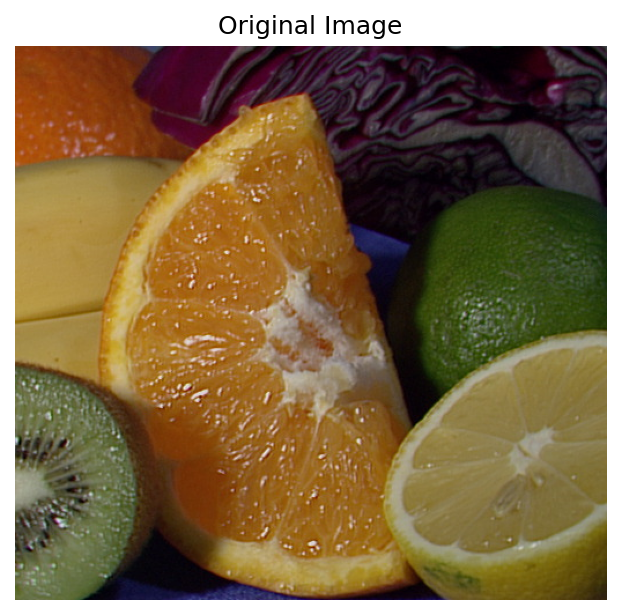

Image shape: (480, 512, 3)


In [10]:
REPO_ROOT = Path("../..")  # HW12/Part_A -> repo root
IMG_NAME = "segmentation_sample.jpg"
IMG_PATH = REPO_ROOT / IMG_NAME

if not IMG_PATH.exists():
    url = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/fruits.jpg"
    req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
    with urllib.request.urlopen(req) as response, open(IMG_PATH, 'wb') as out_file:
        out_file.write(response.read())
    print(f"Downloaded sample image to {IMG_PATH.resolve()}")
else:
    print(f"Image already exists at {IMG_PATH.resolve()}")

image = plt.imread(str(IMG_PATH))
if image.max() <= 1.0:
    image = (image * 255).astype(np.uint8)
if image.ndim == 2:
    image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
elif image.shape[2] == 4:
    image = cv2.cvtColor(image, cv2.COLOR_RGBA2RGB)

height, width, channels = image.shape

plt.figure(dpi=150)
plt.title("Original Image")
plt.imshow(image)
plt.axis("off")
plt.show()

print(f"Image shape: {image.shape}")

---

## Question 1

**Please detail the differences between unsupervised image segmentation methods and supervised semantic image segmentation methods.**

| Aspect | Unsupervised Segmentation | Supervised Semantic Segmentation |
|---|---|---|
| **Training data** | No labelled data required | Requires large pixel-level annotated datasets |
| **Learning paradigm** | Groups pixels by similarity (colour, texture, spatial proximity) without any prior knowledge of object classes | Learns a mapping from pixels to predefined class labels using ground-truth masks |
| **Output** | Clusters / regions with no semantic meaning — segments are just groups of similar pixels | A label map where every pixel is assigned a meaningful class (e.g., *car*, *road*, *sky*) |
| **Typical algorithms** | K-Means, Mean-Shift, Gaussian Mixture Models, spectral clustering, watershed | FCN, U-Net, DeepLab, SegFormer, Mask R-CNN (instance) |
| **Generalization** | Works on any image without retraining; parameters (e.g., *k*) are set manually | Generalizes to unseen images of the same domain but requires retraining for new domains |
| **Computational cost** | Generally lighter at inference (no deep network) | Heavier — requires GPU for training and often for inference |
| **Evaluation** | Hard to evaluate objectively (no ground truth); often visual inspection | Standard metrics: mIoU, pixel accuracy, Dice coefficient |

## Question 2

**Name well-known methods from each of the above categories.**

**Unsupervised image segmentation methods:**
- K-Means clustering
- Mean-Shift clustering
- Gaussian Mixture Models (GMM / Expectation-Maximisation)
- Spectral clustering
- Watershed algorithm
- SLIC Superpixels
- Otsu's thresholding
- Graph-cut / Normalized Cuts

**Supervised semantic segmentation methods:**
- Fully Convolutional Network (FCN) — Long et al., 2015
- U-Net — Ronneberger et al., 2015
- DeepLab (v1–v3+) — Chen et al.
- SegFormer — Xie et al., 2021
- PSPNet (Pyramid Scene Parsing Network)
- Mask R-CNN (instance segmentation)
- HRNet (High-Resolution Network)

---

## Question 3 — K-Means Image Segmentation

### Build feature vectors

Following the reference article [1], we create two representations of the image pixels:

- **`df_1`** — RGB values *plus* pixel (col, row) location  
- **`df_2`** — RGB values only

In [11]:
index = pd.MultiIndex.from_product(
    (*map(range, image.shape[:2]), ("r", "g", "b")),
    names=("row", "col", None),
)
df_1 = pd.Series(image.flatten(), index=index)
df_1 = df_1.unstack()
df_1 = df_1.reset_index().reindex(columns=["col", "row", "r", "g", "b"])

df_2 = df_1[["r", "g", "b"]]

print("df_1 (RGB + location):")
display(df_1.head())
print("\ndf_2 (RGB only):")
display(df_2.head())

df_1 (RGB + location):


,col,row,r,g,b
0,0,0,130,62,13
1,1,0,131,63,14
2,2,0,134,64,15
3,3,0,134,62,14
4,4,0,134,62,14



df_2 (RGB only):


,r,g,b
0,130,62,13
1,131,63,14
2,134,64,15
3,134,62,14
4,134,62,14


### Normalize to 0–1

Pixel values are 0–255 while spatial coordinates can be much larger.  
We normalize every feature to \[0, 1\] with `MinMaxScaler` so Euclidean distance treats all dimensions equally.

In [12]:
nd_1 = MinMaxScaler(feature_range=(0, 1)).fit_transform(df_1)
nd_2 = MinMaxScaler(feature_range=(0, 1)).fit_transform(df_2)

print(f"nd_1 shape: {nd_1.shape}  (col, row, r, g, b)")
print(f"nd_2 shape: {nd_2.shape}  (r, g, b)")

nd_1 shape: (245760, 5)  (col, row, r, g, b)
nd_2 shape: (245760, 3)  (r, g, b)


### Elbow method — optimal *k*

Run K-Means for a range of *k* values on both feature vectors and plot inertia.

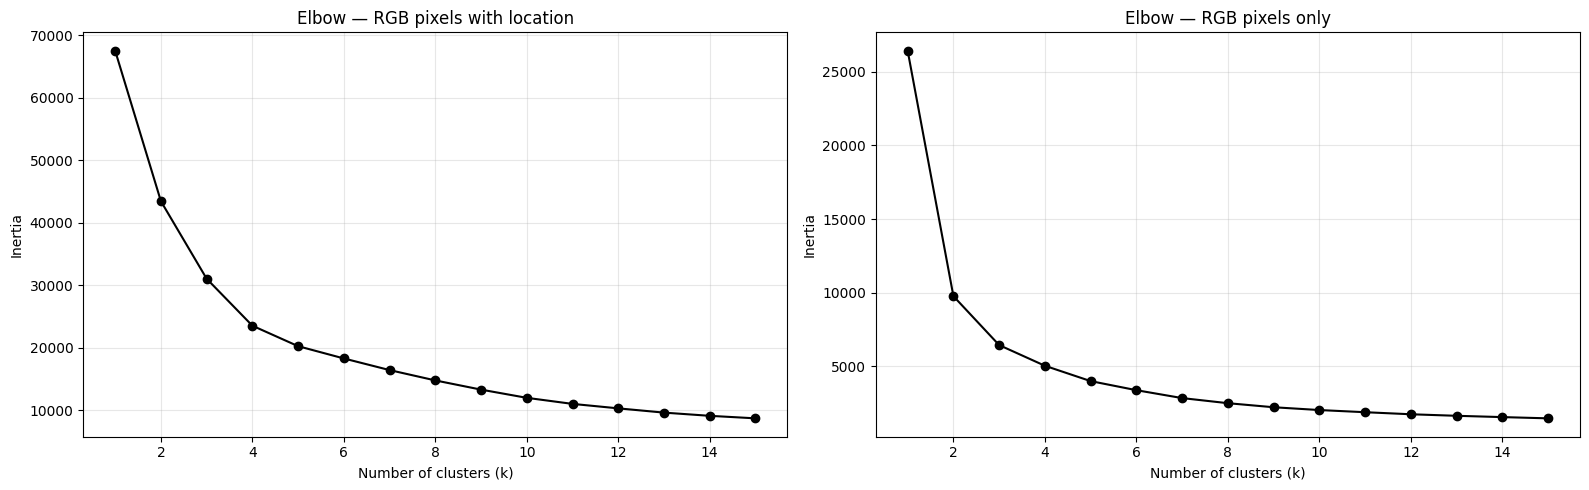

In [13]:
K_RANGE = range(1, 16)

inertias_1 = [KMeans(n_clusters=k, n_init=10, random_state=42).fit(nd_1).inertia_ for k in K_RANGE]
inertias_2 = [KMeans(n_clusters=k, n_init=10, random_state=42).fit(nd_2).inertia_ for k in K_RANGE]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

ax1.plot(list(K_RANGE), inertias_1, "o-", color="black")
ax1.set_xlabel("Number of clusters (k)")
ax1.set_ylabel("Inertia")
ax1.set_title("Elbow — RGB pixels with location")
ax1.grid(True, alpha=0.3)

ax2.plot(list(K_RANGE), inertias_2, "o-", color="black")
ax2.set_xlabel("Number of clusters (k)")
ax2.set_ylabel("Inertia")
ax2.set_title("Elbow — RGB pixels only")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The elbow is generally more visible in the RGB-only plot because the feature space is lower-dimensional.  
The feature vector that includes pixel location descends more smoothly, making the elbow harder to pinpoint — but it produces spatially coherent clusters.

### Apply K-Means with two different *k* values

Based on the elbow plots, we pick two values of *k* and visualise the segmentation for both feature vectors.

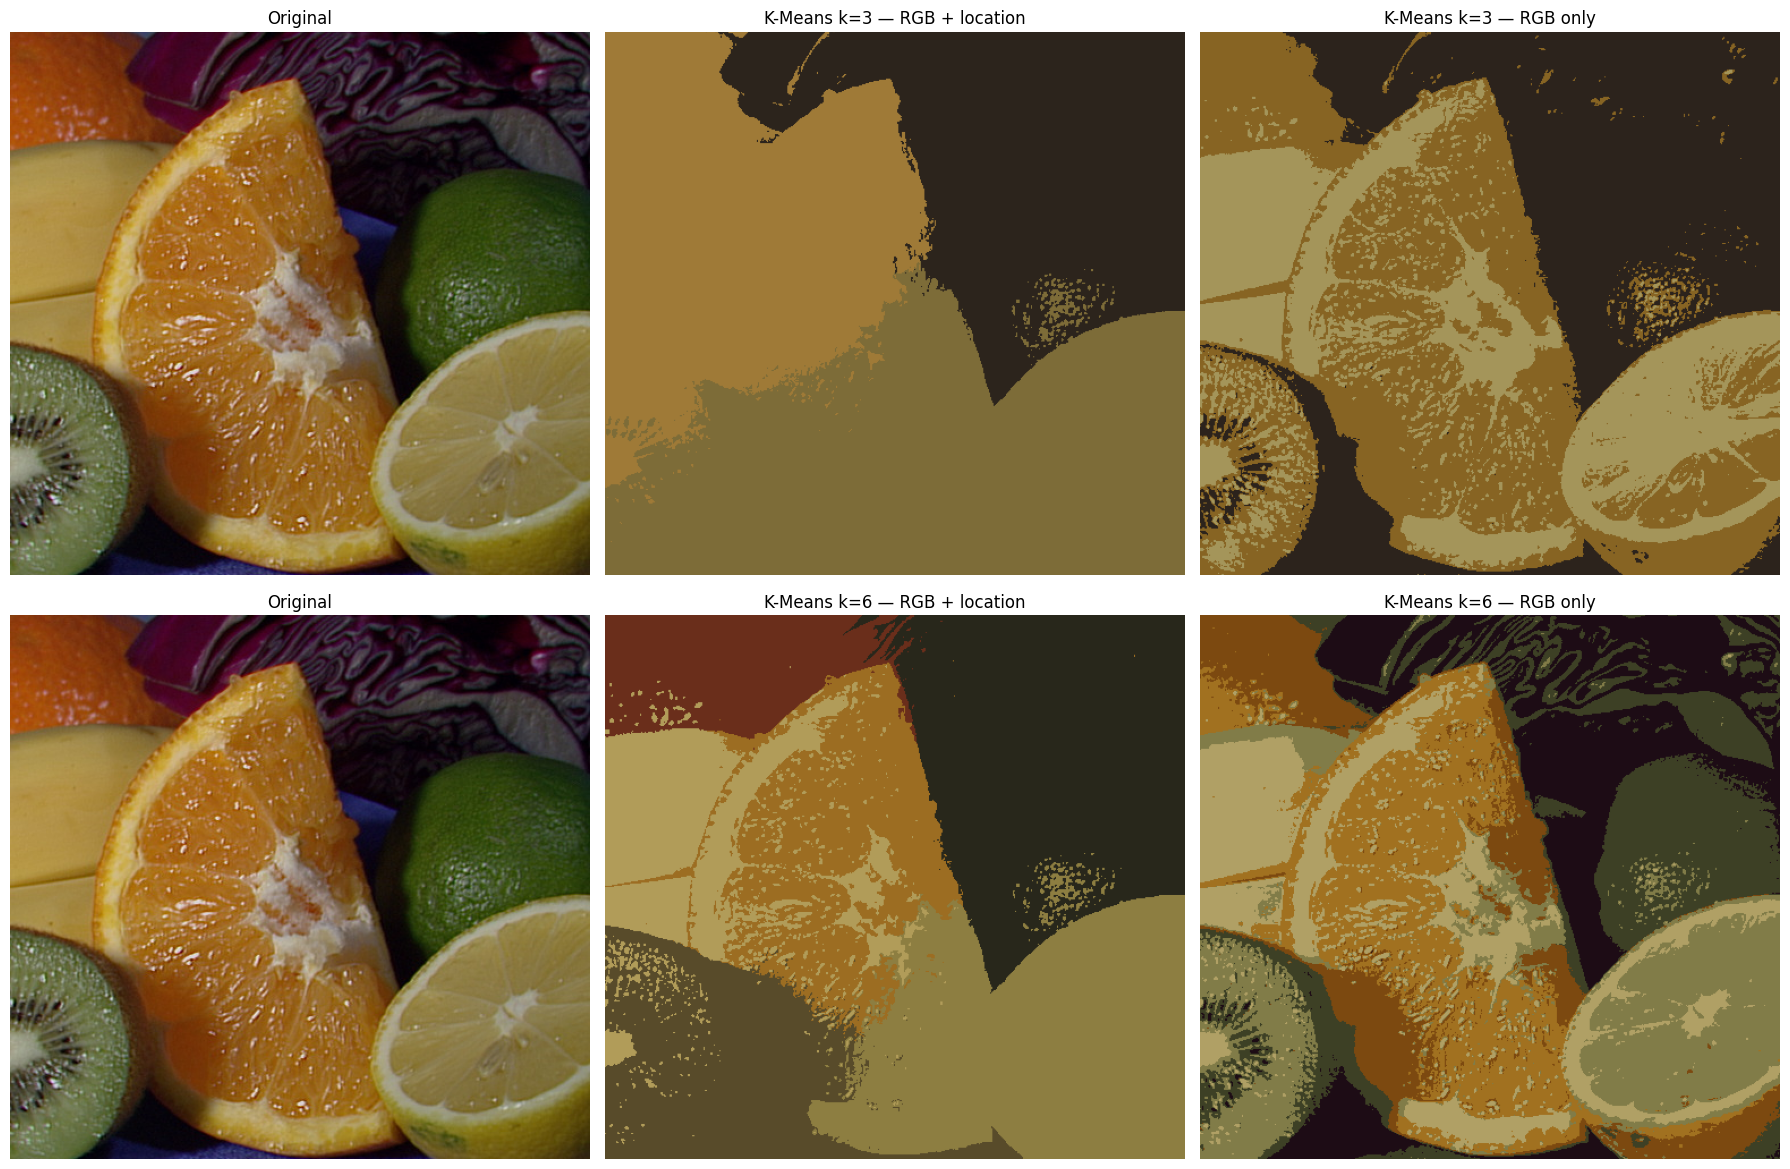

In [14]:
def recreate_image(cluster_centers, labels, w, h):
    """Reconstruct an image from cluster centres and per-pixel labels."""
    return np.clip(cluster_centers[labels].reshape(h, w, 3), 0, 255).astype(np.uint8)


k_values = [3, 6]

fig, axes = plt.subplots(len(k_values), 3, figsize=(18, 6 * len(k_values)))

for row, k in enumerate(k_values):
    # --- with location ---
    km1 = KMeans(n_clusters=k, n_init=10, random_state=42).fit(nd_1)
    rgb_centres_1 = km1.cluster_centers_[:, 2:] * 255  # last 3 cols are r,g,b
    seg1 = recreate_image(rgb_centres_1, km1.labels_, width, height)

    # --- RGB only ---
    km2 = KMeans(n_clusters=k, n_init=10, random_state=42).fit(nd_2)
    rgb_centres_2 = km2.cluster_centers_ * 255
    seg2 = recreate_image(rgb_centres_2, km2.labels_, width, height)

    axes[row, 0].imshow(image)
    axes[row, 0].set_title("Original")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(seg1)
    axes[row, 1].set_title(f"K-Means k={k} — RGB + location")
    axes[row, 1].axis("off")

    axes[row, 2].imshow(seg2)
    axes[row, 2].set_title(f"K-Means k={k} — RGB only")
    axes[row, 2].axis("off")

plt.tight_layout()
plt.show()

Including pixel location in the feature vector produces spatially coherent clusters — nearby pixels of similar colour are grouped together.  
The RGB-only vector segments purely by colour, so distant pixels that happen to share a colour end up in the same cluster.

---

## Question 3.2 — Mean-Shift Clustering

Apply the Mean-Shift algorithm to the same image.  
Mean-Shift does not require specifying the number of clusters — it discovers them automatically via kernel density estimation.  
The critical parameter is the **bandwidth**, estimated here with `estimate_bandwidth`.

In [15]:
bandwidth_1 = estimate_bandwidth(nd_1, quantile=0.06, n_samples=1000)
bandwidth_2 = estimate_bandwidth(nd_2, quantile=0.06, n_samples=1000)

print(f"Bandwidth (with location):  {bandwidth_1:.4f}")
print(f"Bandwidth (RGB only):       {bandwidth_2:.4f}")

Bandwidth (with location):  0.2696
Bandwidth (RGB only):       0.1051


In [16]:
ms_1 = MeanShift(bandwidth=bandwidth_1, bin_seeding=True, cluster_all=True).fit(nd_1)
ms_2 = MeanShift(bandwidth=bandwidth_2, bin_seeding=True, cluster_all=True).fit(nd_2)

print(f"Mean-Shift (with location): {len(ms_1.cluster_centers_)} clusters")
print(f"Mean-Shift (RGB only):      {len(ms_2.cluster_centers_)} clusters")

Mean-Shift (with location): 9 clusters
Mean-Shift (RGB only):      9 clusters


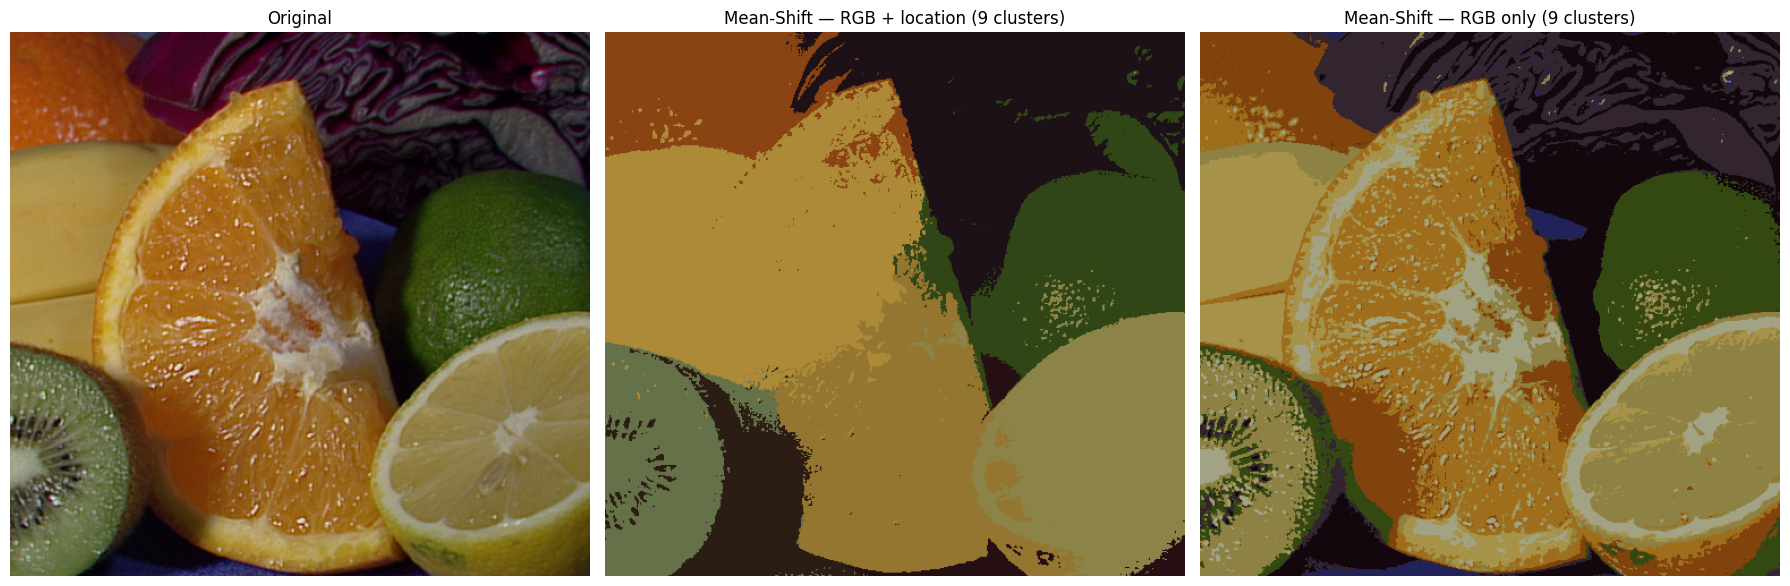

In [17]:
rgb_centres_ms1 = ms_1.cluster_centers_[:, 2:] * 255
seg_ms1 = recreate_image(rgb_centres_ms1, ms_1.labels_, width, height)

rgb_centres_ms2 = ms_2.cluster_centers_ * 255
seg_ms2 = recreate_image(rgb_centres_ms2, ms_2.labels_, width, height)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(image)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(seg_ms1)
axes[1].set_title(f"Mean-Shift — RGB + location ({len(ms_1.cluster_centers_)} clusters)")
axes[1].axis("off")

axes[2].imshow(seg_ms2)
axes[2].set_title(f"Mean-Shift — RGB only ({len(ms_2.cluster_centers_)} clusters)")
axes[2].axis("off")

plt.tight_layout()
plt.show()

The feature vector that includes location information produces better spatial grouping — nearby similar-colour regions are merged, which is more useful for tasks like identifying landing areas or road surfaces.  
The RGB-only vector can over-segment because it ignores spatial proximity.

---

## Question 3.3 — Is Image Thresholding a Form of Unsupervised Image Segmentation?

**Yes.** Image thresholding (e.g., Otsu's method, adaptive thresholding) is one of the simplest forms of unsupervised image segmentation.  

- It partitions pixels into foreground and background (or multiple regions for multi-level thresholding) based solely on intensity values — no labelled training data is required.
- Otsu's method in particular automatically selects the threshold that minimises intra-class variance, which is analogous to how K-Means (with k = 2) partitions data.
- The key distinction from clustering-based methods is that thresholding typically operates on a 1-D histogram (intensity) rather than a multi-dimensional feature space (colour channels, spatial coordinates, texture features).

Because it requires no supervision and groups pixels purely by their statistical properties, thresholding qualifies as **unsupervised segmentation**.

---

## Question 3.4 — Differences Between K-Means and Mean-Shift

| Aspect | K-Means | Mean-Shift |
|---|---|---|
| **Number of clusters** | Must be specified a priori (*k*) | Determined automatically from data density |
| **Cluster shape** | Assumes spherical (Voronoi) clusters | Can discover arbitrarily shaped clusters |
| **Initialization** | Sensitive to initial centroid placement (mitigated by k-means++ / multiple inits) | No initialization needed; each point starts as a candidate |
| **Key parameter** | *k* (number of clusters) | *bandwidth* (kernel radius) |
| **Scalability** | O(n·k·i) — scales well to large datasets | O(n²) per iteration — much slower on large data |
| **Convergence** | Converges to a local minimum of inertia | Converges to local modes of the density function |
| **Outlier handling** | Outliers are forced into the nearest cluster | Outliers can form their own small clusters |

---

## Question 3.5 — Limitations

**K-Means limitations:**
- Requires the number of clusters *k* to be chosen in advance
- Assumes clusters are convex and roughly equal in size
- Sensitive to initial centroid placement — can converge to poor local minima
- Only considers colour similarity; ignores spatial coherence unless location is added to the feature vector
- Not robust to noise or outliers

**Mean-Shift limitations:**
- Computationally expensive — O(n²) makes it impractical on high-resolution images without downsampling or bin seeding
- The bandwidth parameter heavily influences results and is not always easy to choose
- Struggles with high-dimensional feature spaces
- No guarantee on the number of clusters found — small bandwidth can over-segment, large bandwidth can under-segment
- Like K-Means, the basic form uses only colour features without spatial regularization unless location is explicitly included

**Shared limitations:**
- Neither method produces semantically meaningful segments — they group by appearance, not by object identity
- Both are sensitive to the colour space used (RGB vs. LAB vs. HSV can produce very different results)
- Neither inherently handles texture or shape information

---

## Acknowledgment

I used a GPT-5.3-Codex to help scaffold and organize this notebook.

Gemini-3.1 was used to check the result and validate conformity with the assignment outline.

All observations and responses were written by me, Adam Nelson-Archer.